In [18]:
import pandas as pd
import numpy as np
# from tqdm import tqdm
# ============================================================
# 1. Cargar dataset
# ============================================================
# SAVE_DIR = "/content/drive/MyDrive/KYUTECH/Lab research/Research/Anomaly Detection ADCS/Coding/dataset/windowed/"
SAVE_DIR = "./dataset_windows20/"

X = np.load(SAVE_DIR + "X_windows.npy")     # shape: (N, 20, num_features)
y_bin = np.load(SAVE_DIR + "y_binary.npy")  # shape: (N,)
y_ch  = np.load(SAVE_DIR + "y_channel.npy") # shape: (N,), 0 = no fault, 1..18 canal

N, W, F = X.shape

print("=====================================")
print(" Dataset loaded successfully ")
print("=====================================")
print(f"Total windows: {N}")
print(f"Window size: {W}")
print(f"Number of features: {F}")
print(f"Anomalous windows: {sum(y_bin)}")
print(f"Nominal windows: {N - sum(y_bin)}")
print(f"Percentage anomalies: {100 * sum(y_bin)/N:.2f}%")
print("=====================================\n")

 Dataset loaded successfully 
Total windows: 399982
Window size: 20
Number of features: 20
Anomalous windows: 274971
Nominal windows: 125011
Percentage anomalies: 68.75%



In [20]:
import numpy as np

idx_nom = np.where(y_bin == 0)[0]
idx_anom = np.where(y_bin == 1)[0]

print("Nominal windows:", len(idx_nom))
print("Anomalous windows:", len(idx_anom))


Nominal windows: 125011
Anomalous windows: 274971


In [3]:
## Preprocessing

In [24]:
# separar nominales
X_nom = X[y_bin == 0]   # (N_nom, 20, num_features)
# calcular μ y σ por feature
mean_feat = X_nom.mean(axis=(0,1))   # (num_features,)
std_feat  = X_nom.std(axis=(0,1)) + 1e-8
# escalar TODO el dataset
def scale_windows(X, mean, std):
    return (X - mean[None,None,:]) / std[None,None,:]

X_scaled = scale_windows(X, mean_feat, std_feat)


In [25]:
# Balancing dataset
np.random.seed(42)

n_target = len(idx_nom)

idx_anom_sub = np.random.choice(
    idx_anom,
    size=n_target,
    replace=False
)

idx_bal = np.concatenate([idx_nom, idx_anom_sub])
np.random.shuffle(idx_bal)

X_bal = X[idx_bal]
y_bin_bal = y_bin[idx_bal]
y_ch_bal = y_ch[idx_bal]

print("Balanced dataset:")
print("X:", X_bal.shape)
print("Binary labels:", np.bincount(y_bin_bal))


Balanced dataset:
X: (250022, 20, 20)
Binary labels: [125011 125011]


In [23]:
# def variance_based_detector(window, threshold_std=1.0):
#     """
#     window: numpy array (20 x F)
#     Detecta anomalía si algún canal tiene std > threshold
#     """
#     stds = np.std(window, axis=0)
#     return 1 if np.any(stds > threshold_std) else 0
# def adaptive_variance_detector(window, k=1.0):
#     stds = np.std(window, axis=0)
#     mu = np.mean(stds)
#     sigma = np.std(stds)
#     return 1 if np.any(stds > mu + k * sigma) else 0
import pywt
import numpy as np

def compute_dwt_windows(X, wavelet="db4", level=2):
    """
    X: (N_windows, window_size, n_channels) o (N_windows, window_size)
    return:
        A: Approximation coefficients (low-frequency)
        D: Detail coefficients (high-frequency, concatenated)
    """
    if X.ndim == 2:
        X = X[..., np.newaxis]

    N, W, F = X.shape

    A_list = []
    D_list = []

    for i in range(N):
        A_ch = []
        D_ch = []

        for ch in range(F):
            coeffs = pywt.wavedec(X[i, :, ch], wavelet, level=level)

            A = coeffs[0]                  # Approximation
            D = np.concatenate(coeffs[1:]) # All detail levels

            A_ch.append(A)
            D_ch.append(D)

        A_list.append(np.stack(A_ch, axis=1))
        D_list.append(np.stack(D_ch, axis=1))

    return np.array(A_list), np.array(D_list)
A_windows, D_windows = compute_dwt_windows(X)
print("A:", A_windows.shape)
print("D:", D_windows.shape)
def adaptive_threshold_detector_HF(window, thresholds):
    win_max = np.max(window, axis=0)
    return int(np.any(win_max > thresholds))
def adaptive_threshold_detector_LF(window, thresholds):
    win_min = np.min(window, axis=0)
    return int(np.any(win_min < thresholds))
def compute_thresholds(feature_windows, y_bin, k=2.0, mode="high"):
    # feature_windows: (N, coeffs, F)
    nominal = feature_windows[y_bin == 0]

    vals = np.max(nominal, axis=1) if mode == "high" else np.min(nominal, axis=1)

    mu = np.mean(vals, axis=0)
    sigma = np.std(vals, axis=0)

    if mode == "high":
        return mu + k * sigma
    else:
        return mu - k * sigma
TH_D = compute_thresholds(D_windows, y_bin, mode="high")  # spikes
TH_A = compute_thresholds(A_windows, y_bin, mode="low")   # stuck
y_pred_D = np.array([
    adaptive_threshold_detector_HF(w, TH_D)
    for w in D_windows
])

y_pred_A = np.array([
    adaptive_threshold_detector_LF(w, TH_A)
    for w in A_windows
])



/opt/conda/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 2 is too high: all coefficients will experience boundary effects.
  warnings.warn(


A: (399982, 10, 20)
D: (399982, 23, 20)


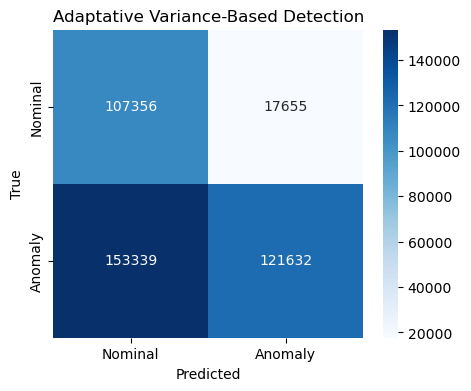

              precision    recall  f1-score   support

           0     0.4118    0.8588    0.5567    125011
           1     0.8732    0.4423    0.5872    274971

    accuracy                         0.5725    399982
   macro avg     0.6425    0.6506    0.5720    399982
weighted avg     0.7290    0.5725    0.5777    399982



In [27]:
y_pred_wavelet = np.logical_or(y_pred_D, y_pred_A).astype(int)

cm = confusion_matrix(y_bin, y_pred_wavelet)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Adaptative Variance-Based Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin, y_pred_wavelet, digits=4))


/opt/conda/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 2 is too high: all coefficients will experience boundary effects.
  warnings.warn(


A: (399982, 10, 20)
D: (399982, 23, 20)


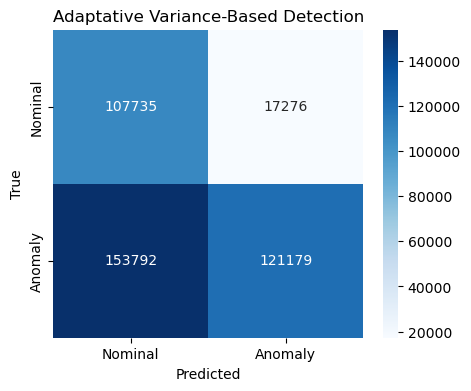

              precision    recall  f1-score   support

           0     0.4119    0.8618    0.5574    125011
           1     0.8752    0.4407    0.5862    274971

    accuracy                         0.5723    399982
   macro avg     0.6436    0.6513    0.5718    399982
weighted avg     0.7304    0.5723    0.5772    399982



In [29]:
A_windows, D_windows = compute_dwt_windows(X_scaled)
print("A:", A_windows.shape)
print("D:", D_windows.shape)
def adaptive_threshold_detector_HF(window, thresholds):
    win_max = np.max(window, axis=0)
    return int(np.any(win_max > thresholds))
def adaptive_threshold_detector_LF(window, thresholds):
    win_min = np.min(window, axis=0)
    return int(np.any(win_min < thresholds))
def compute_thresholds(feature_windows, y_bin, k=2.0, mode="high"):
    # feature_windows: (N, coeffs, F)
    nominal = feature_windows[y_bin == 0]

    vals = np.max(nominal, axis=1) if mode == "high" else np.min(nominal, axis=1)

    mu = np.mean(vals, axis=0)
    sigma = np.std(vals, axis=0)

    if mode == "high":
        return mu + k * sigma
    else:
        return mu - k * sigma
TH_D = compute_thresholds(D_windows, y_bin, mode="high")  # spikes
TH_A = compute_thresholds(A_windows, y_bin, mode="low")   # stuck
y_pred_D = np.array([
    adaptive_threshold_detector_HF(w, TH_D)
    for w in D_windows
])

y_pred_A = np.array([
    adaptive_threshold_detector_LF(w, TH_A)
    for w in A_windows
])
y_pred_wavelet = np.logical_or(y_pred_D, y_pred_A).astype(int)

cm = confusion_matrix(y_bin, y_pred_wavelet)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Adaptative Variance-Based Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin, y_pred_wavelet, digits=4))


/opt/conda/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 2 is too high: all coefficients will experience boundary effects.
  warnings.warn(


A: (250022, 10, 20)
D: (250022, 23, 20)


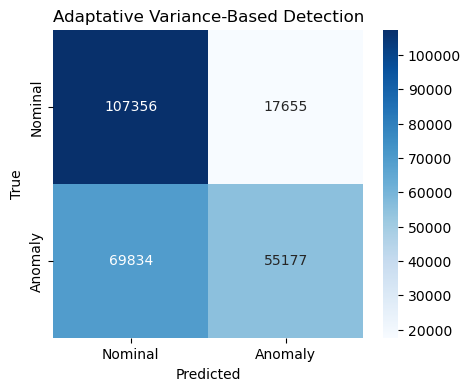

              precision    recall  f1-score   support

           0     0.6059    0.8588    0.7105    125011
           1     0.7576    0.4414    0.5578    125011

    accuracy                         0.6501    250022
   macro avg     0.6817    0.6501    0.6341    250022
weighted avg     0.6817    0.6501    0.6341    250022



In [30]:
A_windows, D_windows = compute_dwt_windows(X_bal)
print("A:", A_windows.shape)
print("D:", D_windows.shape)
def adaptive_threshold_detector_HF(window, thresholds):
    win_max = np.max(window, axis=0)
    return int(np.any(win_max > thresholds))
def adaptive_threshold_detector_LF(window, thresholds):
    win_min = np.min(window, axis=0)
    return int(np.any(win_min < thresholds))
def compute_thresholds(feature_windows, y_bin_bal, k=2.0, mode="high"):
    # feature_windows: (N, coeffs, F)
    nominal = feature_windows[y_bin_bal == 0]

    vals = np.max(nominal, axis=1) if mode == "high" else np.min(nominal, axis=1)

    mu = np.mean(vals, axis=0)
    sigma = np.std(vals, axis=0)

    if mode == "high":
        return mu + k * sigma
    else:
        return mu - k * sigma
TH_D = compute_thresholds(D_windows, y_bin_bal, mode="high")  # spikes
TH_A = compute_thresholds(A_windows, y_bin_bal, mode="low")   # stuck
y_pred_D = np.array([
    adaptive_threshold_detector_HF(w, TH_D)
    for w in D_windows
])

y_pred_A = np.array([
    adaptive_threshold_detector_LF(w, TH_A)
    for w in A_windows
])
y_pred_wavelet = np.logical_or(y_pred_D, y_pred_A).astype(int)

cm = confusion_matrix(y_bin_bal, y_pred_wavelet)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Adaptative Variance-Based Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin_bal, y_pred_wavelet, digits=4))


In [17]:
X.shape, y_bin.shape, y_ch.shape

((399982, 20, 20), (399982,), (399982, 18))